<a href="https://colab.research.google.com/github/abhishek-marathe04/makemore/blob/main/building_makemore_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## We will be following this paper https://jmlr.org/papers/volume3/tmp/bengio03a.pdf

In [2]:
import requests

url = "https://raw.githubusercontent.com/abhishek-marathe04/makemore/refs/heads/main/Indian_names_kaggle.txt"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    words = response.text.replace(".", "").lower().splitlines()
    print(f"Downloaded {len(words)} names.")
    # print(words[:100])  # Show first 100 characters
else:
    print("Failed to download the file.")

Downloaded 55689 names.


In [3]:
words[:10]

['aaban',
 'aabharan',
 'aabhas',
 'aabhat',
 'aabheer',
 'aabheer',
 'abheer',
 'aabher',
 'aabi',
 'aabilesh']

In [4]:
# Build the vocabulary of characters and mappings to/from integers
# print(sorted(list(set(''.join(words)))))
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [5]:
import torch

block_size = 3
X = []
Y = []
for w in words:

  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)

    # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
    context = context[1:] + [ix]


X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [7]:
C = torch.randn(27,2)

In [8]:
C[5]

tensor([0.0539, 1.8466])

In [9]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.0539, 1.8466])

In [10]:
C[X]

tensor([[[ 1.5185, -1.5127],
         [ 1.5185, -1.5127],
         [ 1.5185, -1.5127]],

        [[ 1.5185, -1.5127],
         [ 1.5185, -1.5127],
         [ 0.3465, -0.0509]],

        [[ 1.5185, -1.5127],
         [ 0.3465, -0.0509],
         [ 0.3465, -0.0509]],

        ...,

        [[-1.6189, -1.1456],
         [ 0.8482,  0.8024],
         [ 0.3465, -0.0509]],

        [[ 0.8482,  0.8024],
         [ 0.3465, -0.0509],
         [-0.1485, -0.3001]],

        [[ 0.3465, -0.0509],
         [-0.1485, -0.3001],
         [ 0.3465, -0.0509]]])

In [11]:
C[X].shape

torch.Size([505438, 3, 2])

In [12]:
X[13,2]

tensor(1)

In [13]:
C[X[13,2]]

tensor([ 0.3465, -0.0509])

In [14]:
C[1]

tensor([ 0.3465, -0.0509])

In [15]:
emb = C[X]
emb.shape

torch.Size([505438, 3, 2])

In [16]:
w1 = torch.randn(6,100)
b1 = torch.randn(100)

In [17]:
# emb @ w1
# RuntimeError: mat1 and mat2 shapes cannot be multiplied (111x2 and 6x100)

In [18]:
(emb.view(-1,6) @ w1) + b1

tensor([[ 2.0735, -4.9813, -1.3892,  ..., -1.1140,  0.2023,  1.1676],
        [ 2.2691, -3.9504, -4.0025,  ..., -1.0764,  0.5918,  1.7979],
        [ 3.9031, -1.4052, -5.0664,  ...,  0.1405,  0.8773,  2.2440],
        ...,
        [ 0.4023,  0.7554,  2.9625,  ..., -4.3439,  3.9143, -3.2750],
        [-0.3606, -2.6791, -2.4781,  ...,  1.3423, -1.2108,  2.3309],
        [ 2.1454, -0.7812, -0.3034,  ...,  0.3667,  0.2072,  0.5837]])

In [19]:
h = torch.tanh((emb.view(X.shape[0],6) @ w1) + b1) # Hidden layer activation

In [20]:
h.shape

torch.Size([505438, 100])

In [21]:
# Lets create final layer
# Input is 100 from hidden layer, and output is 27 possible characters
w2 = torch.randn(100,27)
b2 = torch.randn(27)
logits = h @ w2 + b2

In [22]:
logits.shape

torch.Size([505438, 27])

In [23]:
# We will apply softmax
counts = logits.exp()

In [24]:
prob = counts / counts.sum(1, keepdim=True)

In [25]:
prob.shape

torch.Size([505438, 27])

In [26]:
prob[1].sum()

tensor(1.)

In [27]:
torch.arange(32), Y

(tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 tensor([ 1,  1,  2,  ..., 11,  1,  0]))

In [28]:
prob[torch.arange(X.shape[0]), Y]

tensor([1.1379e-02, 6.1271e-02, 1.4529e-01,  ..., 2.9507e-07, 4.5127e-08,
        1.5286e-07])

In [29]:
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(14.6436)

In [30]:
F.cross_entropy(logits, Y)

tensor(14.6436)

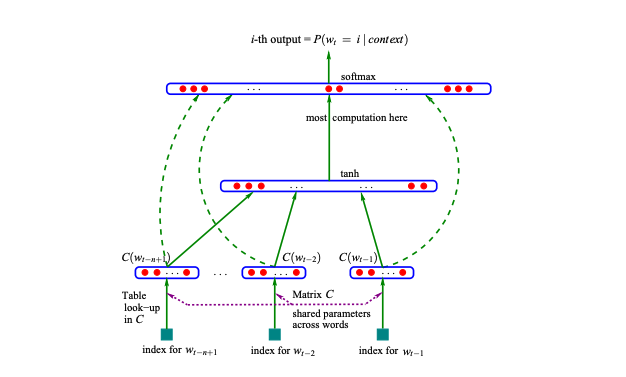

In [31]:
# --------- now made respectable -------

 We will be replicating above neural network where there will be 3 inputs, all will be get indexed to C which is our embedding array. We are storing all characters embedding in 2 dimention format so it will be (27,2) shape.
 Output of this layer would be 6 (2 from each neuron)

 It will then be an input to hidden layer. Our hidden layer will be formed by

> emb * W1 + b1




In [32]:
X.shape, Y.shape

(torch.Size([505438, 3]), torch.Size([505438]))

In [33]:
def initilise_model(hidden_layers=100, embedding_dims=2, input_values=27, output_values=27):

  g = torch.Generator().manual_seed(2147483647) # for reproducability
  C = torch.randn(input_values, embedding_dims, generator=g, requires_grad=True)
  W1 = torch.randn(embedding_dims * 3, hidden_layers,generator=g, requires_grad=True)
  b1 = torch.randn(hidden_layers, generator=g, requires_grad=True)
  W2 = torch.randn(hidden_layers, output_values, generator=g, requires_grad=True)
  b2 = torch.randn(output_values, generator=g, requires_grad=True)
  parameters = [C, W1, b1, W2, b2]
  print("Model initilised..")
  print(f"Hidden Layers : {hidden_layers}, embedding_dims : {embedding_dims}, input_values {input_values}, output_values: {output_values}")
  print(f"Number of parameters in model {sum(p.nelement() for p in parameters)}") # Number of parameters in model
  return C, W1, b1, W2, b2, parameters


In [34]:
# emb = C[X] # (37,3, 2)
# h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
# logits = h @ W2 + b2 # 37,27
# # counts = logits.exp()
# # prob = counts / counts.sum(1, keepdim=True)
# # loss = -prob[torch.arange(37), Y].log().mean()
# loss = F.cross_entropy(logits, Y)
# loss

We should always use cross entrophy from pytorch instead of our own implemention

Below are few reasons

* Model outputs logits (raw, unnormalized scores), not probabilities.
* Manual softmax can break for large logits, e.g. [100, 0, -100] → exp(100) overflows → inf / nan.

* Computing softmax and log manually can cause numerical instability (overflow → inf / nan).

* F.cross_entropy fuses log_softmax + negative log-likelihood using a numerically stable formulation.

* It is faster, more memory-efficient, and produces cleaner gradients.

* Rule: if your model outputs logits, pass them directly to F.cross_entropy — never apply softmax yourself.

In [35]:
# for p in parameters:
#   p.requires_grad = True

In [36]:
# torch.randint(0,X.shape[0], (500,)) # We will form minibatch using this

In [37]:
# Lets identify good learning rate
lre = torch.linspace(-3, 0, 1000)

lrs = 10**lre
# for i in range(10):
#     print(lrs[i].item())
# lrs

In [38]:
C, W1, b1, W2, b2, parameters = initilise_model()

Model initilised..
Hidden Layers : 100, embedding_dims : 2, input_values 27, output_values: 27
Number of parameters in model 3481


In [39]:
lri = []
lossi = []
for i in range(1000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (50,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  loss = F.cross_entropy(logits, Y[ix])
  # loss
  # print(loss.item())
  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = lrs[i]
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad

  # Track loss and lr
  lossi.append(loss.item())
  lri.append(lre[i])


print(loss)

tensor(5.4463, grad_fn=<NllLossBackward0>)


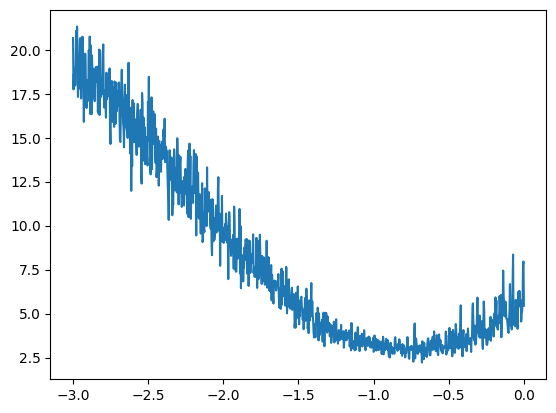

In [40]:
plt.plot(lri, lossi)

From Above Graph, it is clear that good learning exponent is around -1.0 or or 0.1

In [41]:
# Let again initilise everything, Now we know, we will use 0.1 learning rate

C, W1, b1, W2, b2, parameters = initilise_model()

Model initilised..
Hidden Layers : 100, embedding_dims : 2, input_values 27, output_values: 27
Number of parameters in model 3481


In [42]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,X.shape[0], (100,)) # We will form minibatch using this

  emb = C[X[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Y[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(2.1727, grad_fn=<NllLossBackward0>)


In [43]:
  # Print loss for all of X
emb = C[X] # (37,3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Y)
loss

tensor(2.1327, grad_fn=<NllLossBackward0>)

Lets try to split our dataset into training set, dev/evaluation set, test set
80%, 10%, 10%

In [44]:
import torch
import random

def build_dataset(words):
  print(len(words))
  block_size = 3
  X = []
  Y = []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)

      # print(''.join(itos[i] for i in context) ,' -->', itos[ix])
      context = context[1:] + [ix]


  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

44551
5569
5569


In [45]:
Xtr.shape, Xdev.shape, Xte.shape

(torch.Size([404248, 3]), torch.Size([50470, 3]), torch.Size([50720, 3]))

In [46]:
# Lets use train set to train our model and eval/dev set to evaluate
# Initlise model again
C, W1, b1, W2, b2, parameters = initilise_model()

Model initilised..
Hidden Layers : 100, embedding_dims : 2, input_values 27, output_values: 27
Number of parameters in model 3481


In [47]:
# Lets run for 30000 iterations on XTr (Xtrain)
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,Xtr.shape[0], (100,)) # We will form minibatch using this

  emb = C[Xtr[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Ytr[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(2.0057, grad_fn=<NllLossBackward0>)


In [48]:
# Lets evaluate now on Xdev
  # Print loss for all of Xdev
emb = C[Xdev] # (37,3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1383, grad_fn=<NllLossBackward0>)

In [49]:
C

tensor([[ 0.8658, -0.3270],
        [ 0.4829, -0.3528],
        [-0.2913, -0.6745],
        [-1.1522,  0.3528],
        [-0.2673, -0.7021],
        [ 0.1834, -0.1785],
        [-0.2009, -0.3674],
        [ 0.3101,  1.8747],
        [-0.2755, -0.4254],
        [ 0.3274,  0.0515],
        [-0.3778, -0.4511],
        [-0.1936, -0.3603],
        [ 0.2449,  1.7471],
        [-0.3231, -0.3017],
        [-0.3877,  0.0200],
        [ 0.3617, -0.4655],
        [-0.1358, -0.4583],
        [-0.4041, -0.7283],
        [-0.3050, -0.1861],
        [ 0.0095, -0.7147],
        [-0.1045, -0.7822],
        [ 0.6308,  1.2248],
        [-0.4333, -0.4013],
        [-0.2600, -0.4238],
        [ 0.0119, -0.3303],
        [-0.2502, -0.3129],
        [-0.0528, -0.6994]], requires_grad=True)

In [50]:
C[:,0].data, C[:,1].data

(tensor([ 0.8658,  0.4829, -0.2913, -1.1522, -0.2673,  0.1834, -0.2009,  0.3101,
         -0.2755,  0.3274, -0.3778, -0.1936,  0.2449, -0.3231, -0.3877,  0.3617,
         -0.1358, -0.4041, -0.3050,  0.0095, -0.1045,  0.6308, -0.4333, -0.2600,
          0.0119, -0.2502, -0.0528]),
 tensor([-0.3270, -0.3528, -0.6745,  0.3528, -0.7021, -0.1785, -0.3674,  1.8747,
         -0.4254,  0.0515, -0.4511, -0.3603,  1.7471, -0.3017,  0.0200, -0.4655,
         -0.4583, -0.7283, -0.1861, -0.7147, -0.7822,  1.2248, -0.4013, -0.4238,
         -0.3303, -0.3129, -0.6994]))

In [51]:
C.shape[0]

27

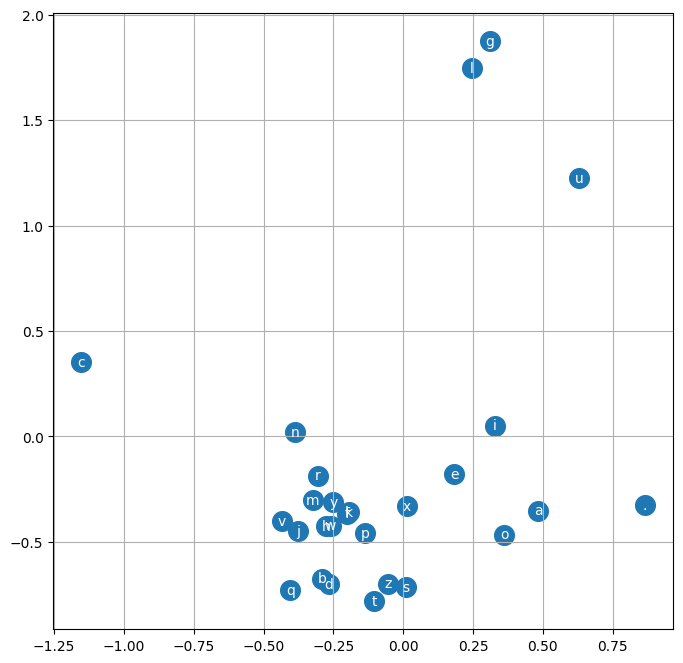

In [52]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

Its fascinating to see how a, e, i and o are closer together as they appear in similar times or fashion in indian names

In [53]:
# Lets try to change some hyperparameters now to see if we can improve model. We have used 2 dimention embedding vector,
# lets try to use 10 dimention now, We can also try some other options like increasing hidden layers to 300

In [54]:
# Let again initilise everything, Now we know, we will use 10 dimentions in C

C, W1, b1, W2, b2, parameters = initilise_model(embedding_dims=10)

Model initilised..
Hidden Layers : 100, embedding_dims : 10, input_values 27, output_values: 27
Number of parameters in model 6097


In [55]:
# Lets run for 30000 iterations
for i in range(30000):
  # Forward pass

  ix = torch.randint(0,Xtr.shape[0], (100,)) # We will form minibatch using this

  emb = C[Xtr[ix]] # (37,3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
  logits = h @ W2 + b2 # 37,27
  # loss
  loss = F.cross_entropy(logits, Ytr[ix])

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  lr = 0.1 if i < 20000 else 0.01
  # Update parameters
  for p in parameters:
      p.data += -lr * p.grad


print(loss)

tensor(2.1144, grad_fn=<NllLossBackward0>)


In [56]:
# Loss is good now
# Lets check for whole Xdev
  # Print loss for all of Xdev
emb = C[Xdev] # (37,3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.0367, grad_fn=<NllLossBackward0>)

In [57]:
# Lets try now same on test set

emb = C[Xte] # (37,3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (37,100)
logits = h @ W2 + b2 # 37,27
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.0242, grad_fn=<NllLossBackward0>)

In [58]:
# Lets now Sample from our model

g = torch.Generator().manual_seed(2147483647 + 102) # for reproducability

for _ in range(20):

  out = []
  context = [0] * block_size # Initilise with all ...
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (37,100)
    logits = h @ W2 + b2 # 37,27
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

dharshini.
havatri.
yahan.
janttug.
sevytheeshika.
carbishanth.
maharshishu.
chantharickaya.
akiyal.
kalath.
mathesh.
kaarejulith.
kaimasadheka.
shrirata.
sajynu.
kulup.
sanan.
sarkena.
vithav.
kalash.


In [59]:
# Lets save all parameters
torch.save({
    "C": C,
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2
}, "model_part2.pt")